In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Ragged cached generation and exact recovery

A cache is part of a computation contract, not just a saved array. This extension links Chapter 5’s RoPE/GQA mechanisms to Day 25’s stopping and policy-version questions. Predict → inspect real tensors → deliberately break a boundary → recover the same continuation.

We use original integer tokens and a random tiny CPU decoder, not pretrained language or a serving engine. All natural greedy paths in the frozen run reached the cap. The stopping demonstration is explicitly forced. [Chapter 5](../../book/chapters/05-building-a-modern-decoder.md) · [specification](../../experiments/specs/2026-10-04-batched-cache-recovery.md) · [report](../../experiments/reports/2026-10-04-batched-cache-recovery.md)


In [2]:
from pathlib import Path
import sys,json,tempfile
from copy import deepcopy
root=Path.cwd().resolve()
while not (root/"src"/"dongxi_llms").is_dir():
    if root.parent==root: raise RuntimeError("Open within Dongxi_LLMs")
    root=root.parent
sys.path.insert(0,str(root/"src"))
import torch,numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from dongxi_llms.batched_cache_lab import (PROMPTS,CONFIG,Generation,PolicySession,
    left_pad,forward,make_model,compare,single_run,save_state,load_state,model_hash,payload)
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","font.family":"DejaVu Sans",
                     "font.size":10,"axes.spines.top":False,"axes.spines.right":False})
model=make_model()
report=json.loads((root/"experiments/reports/2026-10-04-batched-cache-recovery.json").read_text())
result=report["results"]
print("Historical fixed-budget numeric ledger:",report["status"],result["environment"])
print("Current live model identity:",model_hash(model))


Historical fixed-budget numeric ledger: passed {'python': '3.12.14', 'torch': '2.14.1+cpu', 'platform': 'Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39', 'threads': 1, 'precision': 'cpu-float64', 'executable': '/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python'}
Current live model identity: b6e7fd276709f3bc5724f29b847d15b6e322fea773ee8135beb956147af695f3


## Exercise 1 Which states are reused

When one short row finishes, should its cached keys remain in every later model call? Why must each remaining row keep its own position count rather than using its new batch index?

The drawing below is structure, not measured attention or throughput. Both the whole path and the attention close-up preserve token, head and feature axes.


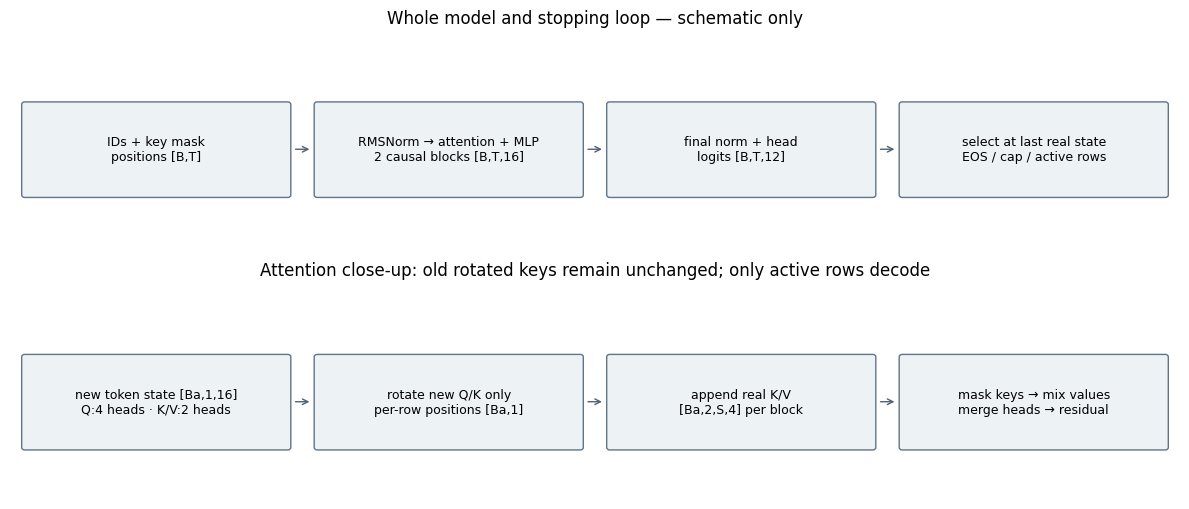

In [3]:
fig,axes=plt.subplots(2,1,figsize=(12,5.2))
for ax in axes:ax.set(xlim=(0,12),ylim=(0,2.5));ax.axis("off")
labels=[["IDs + key mask\npositions [B,T]","RMSNorm → attention + MLP\n2 causal blocks [B,T,16]",
         "final norm + head\nlogits [B,T,12]","select at last real state\nEOS / cap / active rows"],
        ["new token state [Ba,1,16]\nQ:4 heads · K/V:2 heads","rotate new Q/K only\nper-row positions [Ba,1]",
         "append real K/V\n[Ba,2,S,4] per block","mask keys → mix values\nmerge heads → residual"]]
for ax,texts in zip(axes,labels):
    for i,text in enumerate(texts):
        x=.15+3*i
        ax.add_patch(FancyBboxPatch((x,.6),2.7,1.05,boxstyle="round,pad=.03",
                    facecolor="#edf2f5",edgecolor="#617488"))
        ax.text(x+1.35,1.13,text,ha="center",va="center",fontsize=9)
        if i<3:ax.annotate("",xy=(x+2.95,1.13),xytext=(x+2.75,1.13),arrowprops={"arrowstyle":"->","color":"#52616e"})
axes[0].set_title("Whole model and stopping loop — schematic only")
axes[1].set_title("Attention close-up: old rotated keys remain unchanged; only active rows decode")
plt.tight_layout();plt.show()


**Reference:** remove stopped rows from active model work, preserving the mapping to their original request IDs. Position follows the prefix within a request, not batch order. RoPE rotates new Q/K; stored keys already have their rotations. KV remains compact at two heads even though there are four query heads.

![Saved whole decoder and cache attention close-up](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-01.png)


## Exercise 2 Can EOS also be padding

Token 0 is both EOS and PAD here. Predict which zeros are observations and which are dummy storage. Then compare batch outputs against genuinely unpadded single rows.

Change a padding ID while keeping its mask false. Then set all positions to zero. Why is that a different intervention from merely shifting every Q and K by the same RoPE offset?


Per-row full-logit batch/single errors: [0.0, 0.0, 0.0]
All-zero-position max error: 0.0006104385620286229
Real GQA K/V shapes: [(3, 2, 6, 4), (3, 2, 6, 4)] payload bytes: 4608


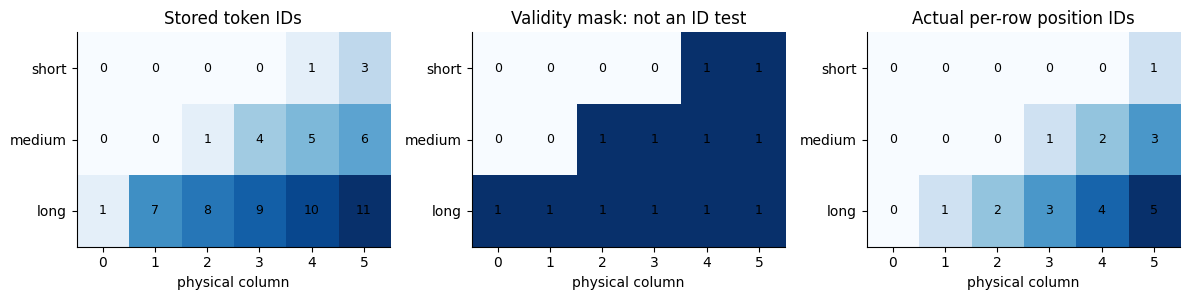

In [4]:
ids,mask,positions=left_pad(list(PROMPTS.values()))
with torch.no_grad():
    actual,cache,key_mask=forward(model,ids,mask,positions)
    wrong,_,_=forward(model,ids,mask,torch.zeros_like(positions))
    errors=[]
    for i,row in enumerate(PROMPTS.values()):
        expected=model(torch.tensor([row]))[0]
        errors.append(float((actual[i,-len(row):]-expected).abs().max()))
print("Per-row full-logit batch/single errors:",errors)
print("All-zero-position max error:",float((actual[mask]-wrong[mask]).abs().max()))
print("Real GQA K/V shapes:",[tuple(k.shape) for k,v in cache],"payload bytes:",payload(cache))
assert max(errors)<1e-10
fig,axes=plt.subplots(1,3,figsize=(12,3.1))
for ax,array,title in zip(axes,[ids.numpy(),mask.numpy(),positions.numpy()],
                        ["Stored token IDs","Validity mask: not an ID test","Actual per-row position IDs"]):
    ax.imshow(array,cmap="Blues",aspect="auto")
    ax.set(xticks=range(6),yticks=range(3),yticklabels=list(PROMPTS),xlabel="physical column",title=title)
    for i in range(3):
        for j in range(6):ax.text(j,i,str(int(array[i,j])),ha="center",va="center",fontsize=9)
plt.tight_layout();plt.show()


**Reference:** left padding is masked out of the valid query’s sources. A valid zero inside a prompt is still a real token. Each real prefix starts its logical positions at zero; dummy zeros have no semantic position. Our all-zero-position broken variant removes relative distances. A uniform shift of both Q/K can cancel in ideal RoPE, so do not claim every offset change necessarily breaks logits. A cached new-token offset inconsistent with its old keys is the relevant failure.

![Saved ragged IDs masks and row-relative positions](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-02.png)


## Exercise 3 Did fewer projected positions imply faster execution

Predict which of single/full, batch/full, single/cache and batch/cache has the most padded work. Does lower forwarded-position count guarantee lower wall time? Reveal the four actual paths and a separate forced stopping control.


single/uncached {'short': 'cap', 'medium': 'cap', 'long': 'cap'} {'ids_equal': True, 'stops_equal': True, 'selected_logp_max_error': 0.0, 'bitwise_records': True}
batch/uncached {'short': 'cap', 'medium': 'cap', 'long': 'cap'} {'ids_equal': True, 'stops_equal': True, 'selected_logp_max_error': 0.0, 'bitwise_records': True}
single/cached {'short': 'cap', 'medium': 'cap', 'long': 'cap'} {'ids_equal': True, 'stops_equal': True, 'selected_logp_max_error': 0.0, 'bitwise_records': True}
batch/cached {'short': 'cap', 'medium': 'cap', 'long': 'cap'} {'ids_equal': True, 'stops_equal': True, 'selected_logp_max_error': 0.0, 'bitwise_records': True}
Forced control, not natural model stopping: {'short': 'eos', 'long': 'eos', 'medium': 'cap'}


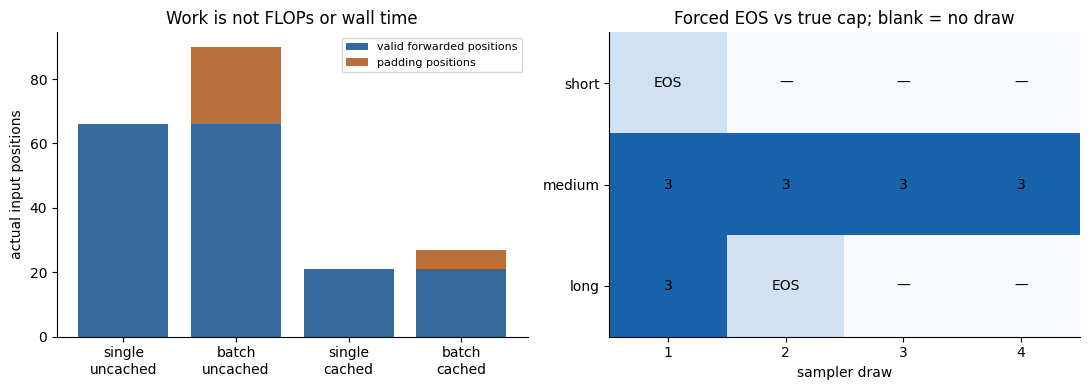

All five historical runtime samples in seconds: {'single/uncached': [0.010292357997968793, 0.007360338990110904, 0.00723910701344721, 0.007233202981296927, 0.007286898005986586], 'batch/uncached': [0.003084932017372921, 0.003040388022782281, 0.0030368669831659645, 0.0030343719990924, 0.003067299985559657], 'single/cached': [0.00767267300398089, 0.007593568996526301, 0.0074808819917961955, 0.0075608819897752255, 0.007489137991797179], 'batch/cached': [0.003125410992652178, 0.003101108013652265, 0.0030968829814810306, 0.003094515996053815, 0.0030987549980636686]}


In [5]:
live={}
for cached in (False,True):
    for batched in (False,True):
        name=("batch" if batched else "single")+("/cached" if cached else "/uncached")
        live[name]=Generation(model,cached=cached).finish() if batched else single_run(model,cached=cached)
        check=compare(live.get("single/uncached",live[name]),live[name])
        assert check["ids_equal"] and check["selected_logp_max_error"]<=1e-10
        print(name,live[name]["stops"],check)
forced=Generation(model,support="forced-stop").finish()
print("Forced control, not natural model stopping:",forced["stops"])
fig,(work,stop)=plt.subplots(1,2,figsize=(11,4))
names=list(live);valid=[live[n]["work"]["valid_input_positions"] for n in names]
pad=[live[n]["work"]["padding_positions"] for n in names]
work.bar(range(4),valid,color="#356a9b",label="valid forwarded positions")
work.bar(range(4),pad,bottom=valid,color="#b97139",label="padding positions")
work.set(xticks=range(4),xticklabels=[n.replace("/","\n") for n in names],ylabel="actual input positions",title="Work is not FLOPs or wall time")
work.legend(fontsize=8)
matrix=np.full((3,4),np.nan)
for i,k in enumerate(PROMPTS):
    for t,row in enumerate(forced["records"][k]):matrix[i,t]=row["token"]
stop.imshow(np.nan_to_num(matrix,nan=-1),cmap="Blues",aspect="auto",vmin=-1,vmax=4)
stop.set(xticks=range(4),xticklabels=[1,2,3,4],yticks=range(3),yticklabels=list(PROMPTS),xlabel="sampler draw",title="Forced EOS vs true cap; blank = no draw")
for i in range(3):
    for j in range(4):stop.text(j,i,"—" if np.isnan(matrix[i,j]) else "EOS" if matrix[i,j]==0 else str(int(matrix[i,j])),ha="center",va="center")
plt.tight_layout();plt.show()
print("All five historical runtime samples in seconds:",result["runtime_samples_seconds"])


**Reference:** cached batch forwards 27 positions, including six pads, for twelve useful output tokens; uncached batch forwards 90, including 24 pads. The uncached single path forwards 66 without padding. These counts are actual model input positions, not all attention arithmetic. In the frozen tiny run, cached batch was slightly slower than uncached batch despite less prefix work. Python, identity checks and small matrices matter.

The forced short row emits EOS immediately, the long row emits token3 then EOS, and the medium row reaches the cap without EOS. After stopping, its row is absent—not another generated PAD token. Raw model likelihood and masked behavior likelihood are recorded separately.

![Saved forwarded versus padded work and per-row stop timeline](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-03.png)


## Exercise 4 Is the next sample already determined by the model weights

Interrupt after two global draws. Predict what is missing if you save only weights: which row is active, which prefixes were consumed, and which random draw comes next?

The reference below saves trusted local data-only state with an external byte digest. Never use this cell to load an arbitrary downloaded checkpoint.


Saved-cache next draw and whole tail are exact. Rebuild comparison: {'ids_equal': True, 'stops_equal': True, 'selected_logp_max_error': 0.0, 'bitwise_records': True}


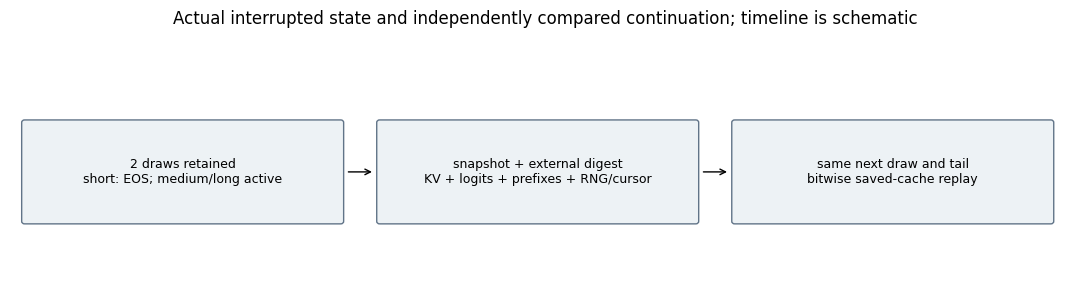

In [6]:
engine=Generation(model,greedy=False);engine.draw();engine.draw()
state=engine.snapshot();contract=engine.contract()
workspace=Path(tempfile.mkdtemp(prefix="dongxi-cache-notebook-"))
saved=save_state(state,workspace/"generation.pt")
next_expected=engine.draw();expected=engine.finish()
loaded=load_state(saved["path"],expected_file_sha256=saved["file_sha256"],expected_contract=contract)
resumed=Generation.restore(model,loaded,expected_contract=contract)
assert resumed.draw()==next_expected
assert resumed.finish()==expected
rebuilt=Generation.restore(model,loaded,expected_contract=contract,rebuild=True).finish()
check=compare(expected,rebuilt)
assert check["ids_equal"] and check["selected_logp_max_error"]<=1e-10
print("Saved-cache next draw and whole tail are exact. Rebuild comparison:",check)
fig,ax=plt.subplots(figsize=(11,3.1));ax.set(xlim=(0,11),ylim=(0,3));ax.axis("off")
labels=["2 draws retained\nshort: EOS; medium/long active",
        "snapshot + external digest\nKV + logits + prefixes + RNG/cursor",
        "same next draw and tail\nbitwise saved-cache replay"]
for i,text in enumerate(labels):
    x=.15+3.65*i
    ax.add_patch(FancyBboxPatch((x,.8),3.25,1.15,boxstyle="round,pad=.03",facecolor="#edf2f5",edgecolor="#617488"))
    ax.text(x+1.625,1.375,text,ha="center",va="center",fontsize=9)
    if i<2:ax.annotate("",xy=(x+3.6,1.375),xytext=(x+3.3,1.375),arrowprops={"arrowstyle":"->"})
ax.set_title("Actual interrupted state and independently compared continuation; timeline is schematic")
plt.tight_layout();plt.show()


**Reference:** weights define distributions, not RNG position or which rows have finished. Saved-cache replay retains the exact computational state. Full-prefix rebuilding is separately tested to the declared tolerance; equality in this tiny fixture does not promise bitwise agreement on another device. Cache storage includes padding but validity prevents using those keys.

![Saved interrupted state and exact continuation contract](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-04.png)


## Exercise 5 The process stopped after collecting a rollout

Should resume sample a new rollout or apply the one already collected? Run a real two-stage tiny RLVR update, then inspect all fixed-budget DPO/RLVR recovery controls. The objective is recovery equivalence, not learning success.


In [7]:
session=PolicySession("rlvr",2521)
session.update()
try:session.update(interrupt_after_collection=True)
except InterruptedError as error:print("Retained interruption:",error)
pending=session.snapshot();expected_update=session.update()
restored=PolicySession("rlvr",2521);restored.restore(pending)
assert restored.pending is not None
assert restored.update()==expected_update
print("Pending IDs/version/cursor:",pending["pending"]["indices"],pending["pending"]["version"],pending["pending"]["cursor_after_collection"])
print("The same collected tokens are applied; no second collection.")


Retained interruption: Declared post-collection interruption; pending batch retained
Pending IDs/version/cursor: [0] 1 2
The same collected tokens are applied; no second collection.


**Reference:** the pending batch is coupled to its old-policy byte identity, version, data cursor and saved likelihoods. Recollecting it advances both data and RNG and is a different experiment. A completed-boundary checkpoint additionally retains Adam moments and the frozen reference. This interface applies only to the tiny local sessions—not the optional pretrained Spark runners.


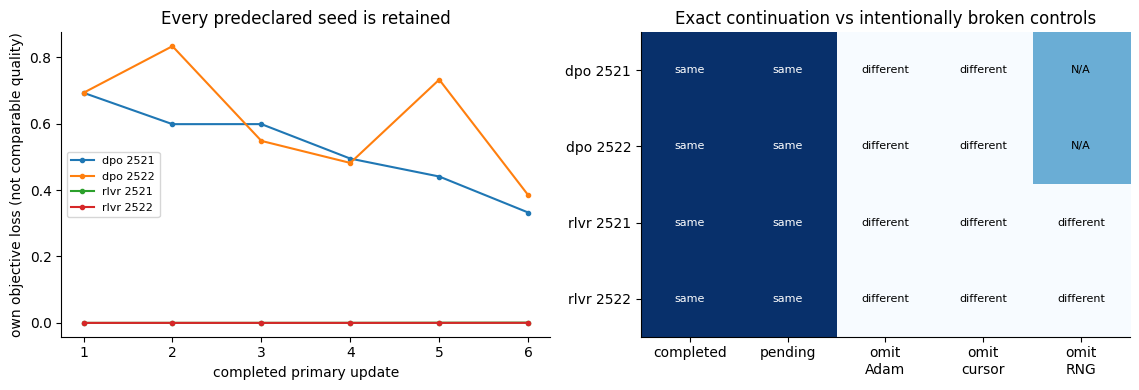

dpo 2521 all six primary records: [(0.6931471805599453, 1.559487310171559, None), (0.598692820196516, 2.335146523188716, None), (0.5988142393677749, 2.021264777176416, None), (0.49491615311256726, 1.457959148936284, None), (0.4409578120283323, 1.236522858433226, None), (0.33252757916139863, 1.3631882454852617, None)]
dpo 2522 all six primary records: [(0.6931471805599453, 2.3936431134040044, None), (0.8336365977170778, 3.333343615562709, None), (0.548249042423726, 1.8980854013012434, None), (0.4819071232407068, 1.5494791577578686, None), (0.7328928169893199, 2.4733416270472763, None), (0.3849496001884598, 1.3213368033907043, None)]
rlvr 2521 all six primary records: [(-5.551115123125783e-17, 2.214826979742422, [1.0, 0.0, 0.0, 0.0]), (0.00011459198172094401, 0.004164379193665539, [0.0, 0.0, 0.0, 0.0]), (0.00010727077025216254, 0.004613540318582833, [0.0, 0.0, 0.0, 0.0]), (0.00018986986563990227, 3.000617480219386, [1.0, 0.0, 0.0, 0.0]), (0.0005417207810117864, 0.012735524786453524, [0.0

In [8]:
runs=result["training"]
fig,(curve,heat)=plt.subplots(1,2,figsize=(11.5,4))
for r in runs:
    curve.plot([h["update"] for h in r["history"]],[h["loss"] for h in r["history"]],marker=".",label=f'{r["objective"]} {r["seed"]}')
curve.set(xlabel="completed primary update",ylabel="own objective loss (not comparable quality)",title="Every predeclared seed is retained");curve.legend(fontsize=8)
cols=["completed","pending","omit Adam","omit cursor","omit RNG"]
matrix=np.array([[float(all(r["exact_recovery"]["completed"].values())),float(all(r["exact_recovery"]["pending"].values())),
                  float(r["omitted_state_controls"]["optimizer"]["history_equal"]),float(r["omitted_state_controls"]["cursor"]["history_equal"]),
                  np.nan if not r["omitted_state_controls"]["rng"]["applicable"] else float(r["omitted_state_controls"]["rng"]["history_equal"])] for r in runs])
heat.imshow(np.nan_to_num(matrix,nan=.5),vmin=0,vmax=1,cmap="Blues",aspect="auto")
heat.set(xticks=range(5),xticklabels=[s.replace(" ","\n") for s in cols],yticks=range(4),
         yticklabels=[f'{r["objective"]} {r["seed"]}' for r in runs],title="Exact continuation vs intentionally broken controls")
for i in range(4):
    for j in range(5):heat.text(j,i,"N/A" if np.isnan(matrix[i,j]) else "same" if matrix[i,j] else "different",ha="center",va="center",fontsize=8,color="white" if matrix[i,j]==1 else "black")
plt.tight_layout();plt.show()
for r in runs:print(r["objective"],r["seed"],"all six primary records:",[(h["loss"],h["gradient_norm"],h.get("reward")) for h in r["history"]])


**Reference:** all completed and pending recoveries reproduce next batches, losses, model bytes, optimizer state, data cursor and rollout RNG. Every applicable omitted-state control changes continuation. DPO does not consume rollout randomness here, so omitting that RNG is deliberately marked N/A, not a contrived failure.

RLVR includes zero-reward groups, near-zero gradients and later successes; a small loss or perfect replay is not proof of better capability. Four primary six-update runs are 24 updates, while two replays and three negative branches add 60 more optimizer calls. Runtime samples and retained cache payload are tiny CPU measurements, not Spark throughput, whole-system memory, or production PPO evidence.

![Saved all-seed objective histories and exact recovery control matrix](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-05.png)


## Exercise 6 Can checking a sampler accidentally change the experiment?

Predict what happens when a checkpoint verifier redraws the historical source IDs. Must those checks use the live training generator? Compare private replay with the intentionally broken live-generator check below. This is a bounded CPU RNG microscope, not a model run or proof that the production snapshot reader is fully budgeted.

The fixed example has three completed updates, two draws per update and five possible source IDs. Change `completed_updates` only after predicting how the private replay count changes. Why does matching the old cursor not mean that verification cost zero work?


Measured scalar draws: {'retained_training_history': 6, 'private_validation': 6, 'safe_future_training': 6, 'independent_comparison_future': 6, 'broken_check_consumed_live': 6, 'broken_future_training': 6}
Expected next source IDs: [1, 2, 4, 1, 3, 4]
After private check: [1, 2, 4, 1, 3, 4]
After broken live check: [1, 2, 2, 4, 3, 4]


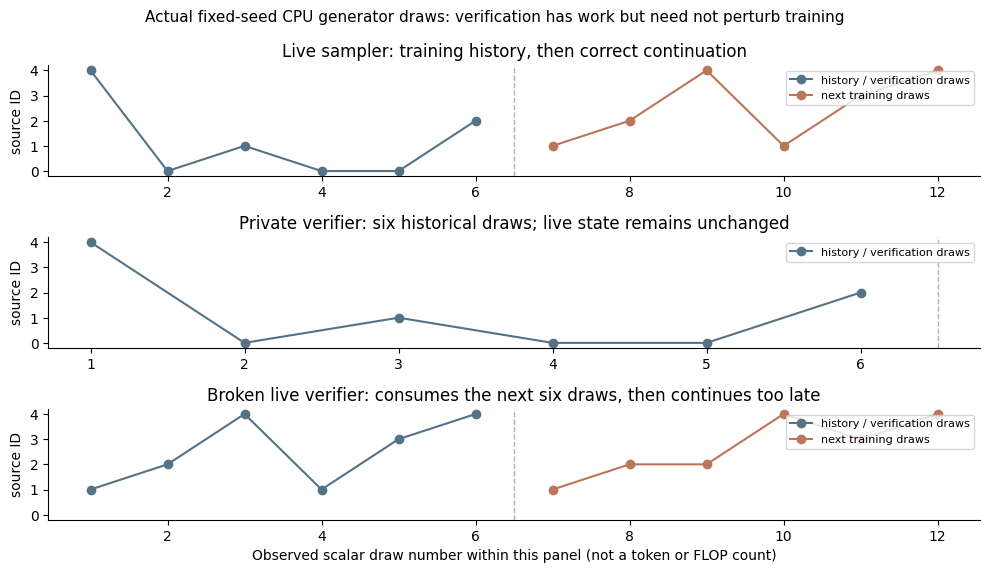

In [9]:
from dongxi_llms.recovery_rng_lab import sampler_verification
check = sampler_verification(seed=1818, completed_updates=3, accumulation=2, source_count=5, future_updates=3)
assert check['private_state_matches']
assert check['live_unchanged_by_private_check']
assert check['safe_next_matches']
print('Measured scalar draws:', check['draws'])
print('Expected next source IDs:', check['expected_next_ids'])
print('After private check:', check['safe_next_ids'])
print('After broken live check:', check['broken_next_ids'])
fig, axes = plt.subplots(3, 1, figsize=(10, 5.8), sharey=True)
panels = [
    ('Live sampler: training history, then correct continuation', check['history'], check['safe_next_ids']),
    ('Private verifier: six historical draws; live state remains unchanged', check['private_replay'], []),
    ('Broken live verifier: consumes the next six draws, then continues too late', check['broken_check_ids'], check['broken_next_ids']),
]
for ax, (title, first, second) in zip(axes, panels):
    ax.plot(range(1, len(first)+1), first, 'o-', color='#547387', label='history / verification draws')
    if second:
        ax.plot(range(len(first)+1, len(first)+len(second)+1), second, 'o-', color='#ba7659', label='next training draws')
    ax.axvline(len(first)+.5, color='#acb4ba', linestyle='--', linewidth=1)
    ax.set(title=title, ylabel='source ID', yticks=range(5))
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Observed scalar draw number within this panel (not a token or FLOP count)')
fig.suptitle('Actual fixed-seed CPU generator draws: verification has work but need not perturb training', fontsize=11)
plt.tight_layout(); plt.show()


**Reference:** the private verifier really makes six draws: three completed updates times two draws per update. It reconstructs the saved historical sampler state while leaving the live generator untouched, so the next six training IDs still match the independent continuation from the saved state. The broken checker starts from that saved state and consumes the next six live draws; the following training IDs now come from a later state. Rejecting the checkpoint afterward would not undo those consumed draws. Compare generator states as well as sampled IDs: individual IDs can match by chance.

Each actual semantic validation must reserve its own declared work before replay, including repeated callbacks and restore checks. The SFT selector in this course is deterministic and does not acquire invented random draws. This figure is not an exact CPU-instruction, memory or wall-time accounting tool.

The shared reader verifies payload bytes, deserializes and performs generic tree/finite checks before the runner callback. An internal saved journal prefix cannot authorize that earlier work. Exercise7 uses a separate retained receipt and actual pre-read I/O admission; the semantic callback remains a distinct charge. See Chapter14 deep questions29–32 and their worked solutions.

![Saved private replay and broken live verification draw comparison](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-06.png)


## Exercise7 — reading a checkpoint must not be a free retry

**Predict:** two successful loads produce identical weights. A third load reads the same bytes but its semantic callback rejects the state. After reopening the journal from the checkpoint's older receipt, should a fourth load receive a fresh allowance? Why must the receipt live outside the tensor payload?

The following microscope really saves, inspects and loads a tiny CPU tensor through the shared reader. Its separate I/O allowance permits three load attempts. It deliberately rejects the third callback, reopens the same physical journal from the retained pre-save prefix, then attempts a fourth load. No pretrained model, CUDA, service or physical quota is used. The reader's nine units do not replace the runner's SFT/DPO semantic costs.


Deliberate failure: declared deliberate semantic rejection after generic read
Fourth load: Whole operation refused before work: snapshot_load_operations
Actual payload bytes: 3049


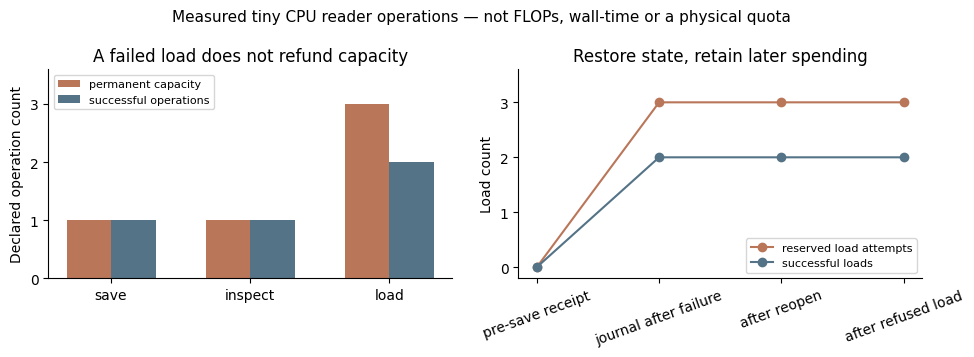

In [10]:
from dongxi_llms.snapshot_io_lab import reader_admission_example
trace = reader_admission_example()
assert trace['numerical_state_equal']
assert trace['later_spending_retained'] and trace['refused_before_new_ticket']
print('Deliberate failure:', trace['failure'])
print('Fourth load:', trace['refusal'])
print('Actual payload bytes:', trace['payload_bytes'])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
names = ['save', 'inspect', 'load']
x = np.arange(3)
axes[0].bar(x-.16, [trace['reserved'][f'snapshot_{name}_operations'] for name in names], width=.32, color='#ba7659', label='permanent capacity')
axes[0].bar(x+.16, [trace['completed'][f'snapshot_{name}_operations'] for name in names], width=.32, color='#547387', label='successful operations')
axes[0].set(xticks=x, xticklabels=names, ylabel='Declared operation count', title='A failed load does not refund capacity', ylim=(0, 3.6))
axes[0].legend(fontsize=8)
labels = ['pre-save receipt', 'journal after failure', 'after reopen', 'after refused load']
axes[1].plot(range(4), [row['reserved'] for row in trace['load_trace']], 'o-', color='#ba7659', label='reserved load attempts')
axes[1].plot(range(4), [row['completed'] for row in trace['load_trace']], 'o-', color='#547387', label='successful loads')
axes[1].set(xticks=range(4), xticklabels=labels, ylabel='Load count', title='Restore state, retain later spending', ylim=(-.2, 3.6))
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)
fig.suptitle('Measured tiny CPU reader operations — not FLOPs, wall-time or a physical quota', fontsize=11)
plt.tight_layout(); plt.show()


**Reference:** the third attempt consumed a payload read and generic checks even though it never became a successful load. Reopening an older numerical checkpoint must keep that later attempted work. The fourth load is refused before a new ticket or payload read; identical weights do not imply a free operation.

The external receipt binds the exact payload bytes, scientific/I/O contracts and pre-save journal prefix. The payload must agree with that receipt before runner semantics or application. Save completion cannot be placed inside its own already-written payload, so it remains in the later journal history. The adjacent commit marker alone is not trusted bootstrap evidence. These are trusted-local checks, not authentication against malicious writers or cross-machine recovery. Metadata/journal processing, caller state capture, artifact inventory, application and other outputs remain separate boundaries.

![Actual reader capacity and successful operations](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-07.png)


## Exercise8 — two applied updates do not identify the whole boundary

**Predict:** two snapshots both contain exactly two applied policy updates. One already holds the next sampled group; the other does not. Should their first resumed action, source cursor and sampling RNG advance be identical? Can the later rejected read be erased when the older snapshot is restored?

This microscope uses the original random tiny local Qwen geometry and native RLVR functions:16-token authored alphabet, group3, cap4, horizon4, seed2323, AdamW0.008, population advantages and temperature1/full-support sampling. It manually publishes one boundary per arm, deliberately rejects one read, reopens both same physical journals, then restores and finishes the original trajectory. Its actual operation counts are not the complete runner lifecycle's publication schedule. No pretrained checkpoint, CUDA, server, external job or Mac execution is used. [Predeclared protocol](../../experiments/specs/2026-10-05-rlvr-reader-lesson.md)


/tmp/dongxi-course-reproduction.ZfVaEu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


completed | saved applied updates: 2 | source cursor: 2 | first action: collect then apply
  new collections: 1 | sampling RNG advanced: True
  retained IDs: None | exact replay: True
pending | saved applied updates: 2 | source cursor: 3 | first action: apply retained pool
  new collections: 0 | sampling RNG advanced: False
  retained IDs: [[13, 7, 0, 0], [15, 10, 12, 11], [0, 0, 0, 0]] | exact replay: True


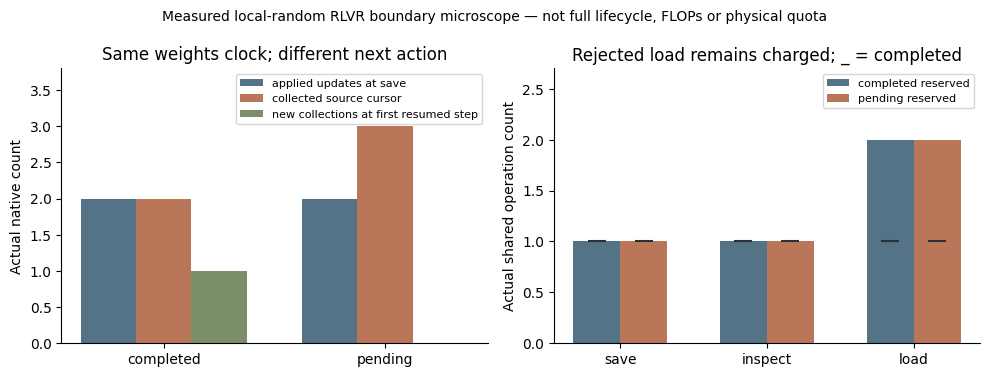

In [11]:
from dongxi_llms.rlvr_snapshot_io_lab import phase_recovery_example
phase_trace = phase_recovery_example(2323)
phase_rows = phase_trace['rows']
assert all(row['exact_recovery'] and row['first_record_equal'] and row['later_work_retained'] for row in phase_rows)
assert phase_rows[0]['final_numerical_sha256'] == phase_rows[1]['final_numerical_sha256']
for row in phase_rows:
    print(row['phase'], '| saved applied updates:', row['completed_updates'], '| source cursor:', row['source_cursor'], '| first action:', row['first_action'])
    print('  new collections:', row['new_collections_at_first_step'], '| sampling RNG advanced:', row['sampling_rng_advanced_at_first_step'])
    print('  retained IDs:', row['pending_ids'], '| exact replay:', row['exact_recovery'])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
x = np.arange(len(phase_rows)); width = .25
axes[0].bar(x-width, [r['completed_updates'] for r in phase_rows], width, color='#547387', label='applied updates at save')
axes[0].bar(x, [r['source_cursor'] for r in phase_rows], width, color='#ba7659', label='collected source cursor')
axes[0].bar(x+width, [r['new_collections_at_first_step'] for r in phase_rows], width, color='#7b8d69', label='new collections at first resumed step')
axes[0].set(xticks=x, xticklabels=[r['phase'] for r in phase_rows], ylabel='Actual native count', title='Same weights clock; different next action', ylim=(0, 3.8))
axes[0].legend(fontsize=8)
names = ['save', 'inspect', 'load']; positions = np.arange(3)
for offset, row, color in zip((-.16, .16), phase_rows, ('#547387', '#ba7659')):
    axes[1].bar(positions+offset, [row['io_reserved'][f'snapshot_{name}_operations'] for name in names], .32, color=color, label=row['phase']+' reserved')
    axes[1].scatter(positions+offset, [row['io_completed'][f'snapshot_{name}_operations'] for name in names], color='#25313b', marker='_', s=180)
axes[1].set(xticks=positions, xticklabels=names, ylabel='Actual shared operation count', title='Rejected load remains charged; _ = completed', ylim=(0, 2.7))
axes[1].legend(fontsize=8)
fig.suptitle('Measured local-random RLVR boundary microscope — not full lifecycle, FLOPs or physical quota', fontsize=10)
plt.tight_layout(); plt.show()


**Reference:** a completed boundary needs its next collection before applying update3. The pending boundary already contains that realized group, so its first application adds zero collections and does not advance the training sampling generator. Both restore update2 and recover the identical original four-update numerical history, including the original reference and optimizer. The retained response IDs are data, not an invitation to sample a more favorable group.

Both arms actually reserve one save, one inspect and two loads; only one load completes because the other callback deliberately rejects it. Reopening the journals preserves that rejected attempt and the later save-validation work. The saved runner23-prefix precedes its semantic save checks; the I/O prefix precedes the shared save reservation. Their independent receipt binds those exact saved prefixes, while each physical journal retains its later suffix. No charge is moved into an already-written payload.

The full native lifecycle also republishes the restored boundary into the new invocation. With U total updates and k completed, fresh/completed-resume/pending-resume save counts are respectively1+2U,1+2(U-k),2+2(U-k-1). These are source-derived operation schedules, not the microscope's measured counts, numerical quality or retry authorization. A pending state at k=U is invalid. Compare [Chapter13§13.7.1](../../book/chapters/13-group-relative-policy-optimization.md) and [Chapter14 worked answer33](../../book/solutions/14-when-optimization-goes-wrong.md).

![Actual native completed and pending first actions with permanent reader spending](../figures/chapter-14/day-25-02_ragged_kv_cache_and_exact_recovery-08.png)
